# Exploratory Data Analysis of a Colorectal Cancer Dataset

This project explores a colorectal cancer dataset using Python, Pandas, Matplotlib, and Seaborn.

The main goal of this analysis is to investigate relationships between clinical, lifestyle, and demographic factors and patient outcomes.

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading the CSV dataset
df = pd.read_csv("colorectal_cancer_dataset.csv")

In [3]:
#displaying the first 5 rows of the dataset
df.head()

,Patient_ID,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,...,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status,Survival_Prediction
0,1,UK,77,M,Localized,69,No,No,Yes,Overweight,...,Yes,No,54413,50,5,Urban,Developed,Moderate,Insured,Yes
1,2,UK,59,M,Localized,33,No,No,No,Overweight,...,Yes,No,76553,37,25,Urban,Developing,High,Uninsured,Yes
2,3,Japan,66,M,Regional,17,No,Yes,No,Normal,...,Yes,No,62805,54,27,Urban,Developed,Moderate,Uninsured,No
3,4,USA,83,M,Regional,14,No,No,No,Obese,...,Yes,No,89393,45,11,Urban,Developed,Moderate,Insured,Yes
4,5,France,66,M,Localized,34,No,Yes,No,Normal,...,Yes,No,66425,15,27,Urban,Developing,High,Insured,Yes


In [4]:
#checking dataset dimensions
df.shape

(167497, 28)

In [5]:
#getting general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167497 entries, 0 to 167496
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   Patient_ID                  167497 non-null  int64 
 1   Country                     167497 non-null  object
 2   Age                         167497 non-null  int64 
 3   Gender                      167497 non-null  object
 4   Cancer_Stage                167497 non-null  object
 5   Tumor_Size_mm               167497 non-null  int64 
 6   Family_History              167497 non-null  object
 7   Smoking_History             167497 non-null  object
 8   Alcohol_Consumption         167497 non-null  object
 9   Obesity_BMI                 167497 non-null  object
 10  Diet_Risk                   167497 non-null  object
 11  Physical_Activity           167497 non-null  object
 12  Diabetes                    167497 non-null  object
 13  Inflammatory_Bowel_Disease  1

In [6]:
#checking missing values in the dataset
df.isnull().sum()

Patient_ID                    0
Country                       0
Age                           0
Gender                        0
Cancer_Stage                  0
Tumor_Size_mm                 0
Family_History                0
Smoking_History               0
Alcohol_Consumption           0
Obesity_BMI                   0
Diet_Risk                     0
Physical_Activity             0
Diabetes                      0
Inflammatory_Bowel_Disease    0
Genetic_Mutation              0
Screening_History             0
Early_Detection               0
Treatment_Type                0
Survival_5_years              0
Mortality                     0
Healthcare_Costs              0
Incidence_Rate_per_100K       0
Mortality_Rate_per_100K       0
Urban_or_Rural                0
Economic_Classification       0
Healthcare_Access             0
Insurance_Status              0
Survival_Prediction           0
dtype: int64

In [7]:
#generating statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,167497.0,83749.000000,48352.363357,1.0,41875.0,83749.0,125623.0,167497.0
Age,167497.0,69.200780,11.872470,30.0,59.0,69.0,79.0,89.0
Tumor_Size_mm,167497.0,42.005708,21.672206,5.0,23.0,42.0,61.0,79.0
Healthcare_Costs,167497.0,72452.168099,27402.779597,25000.0,48760.0,72344.0,96227.0,119999.0
Incidence_Rate_per_100K,167497.0,34.531562,14.447970,10.0,22.0,35.0,47.0,59.0
Mortality_Rate_per_100K,167497.0,17.023875,7.208766,5.0,11.0,17.0,23.0,29.0


### Initial Observations
-> The average age is approximately 69, indicating that colorectal cancer is more common in older populations. 

-> Tumor sizes vary widely, which suggests the presence of both early and advanced stage patients in the dataset.

-> Healthcare costs vary widely, which may reflect differences in economic conditions across countries.


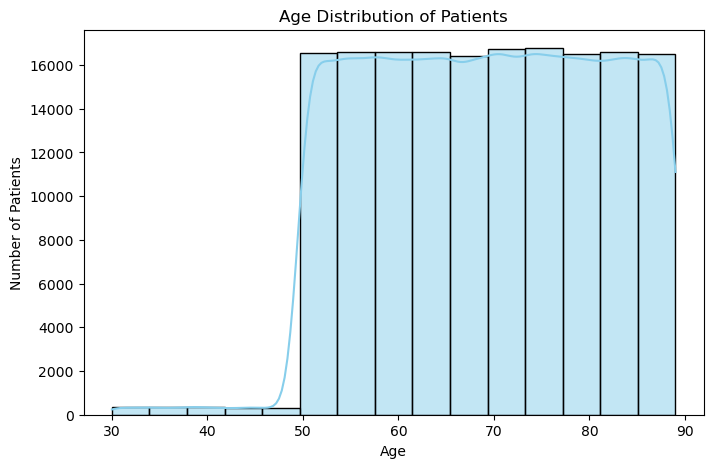

In [8]:
#visualizing the age distribution of the patients
plt.figure(figsize = (8,5))
sns.histplot(df["Age"], bins = 15, color = "skyblue", kde = True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

### Age Distribution Analysis
-> Most patients in the dataset are between the ages of 50 and 90.

-> The distribution suggests that colorectal cancer risk increases significantly with age.

In [9]:
#counting the number of patients in each cancer stage
stage_counts = df["Cancer_Stage"].value_counts()
#convert index to regular column
stage_counts = stage_counts.reset_index()
stage_counts.columns = ["Cancer Stage", "Patient Count"]
stage_counts


,Cancer Stage,Patient Count
0,Regional,66981
1,Localized,66799
2,Metastatic,33717


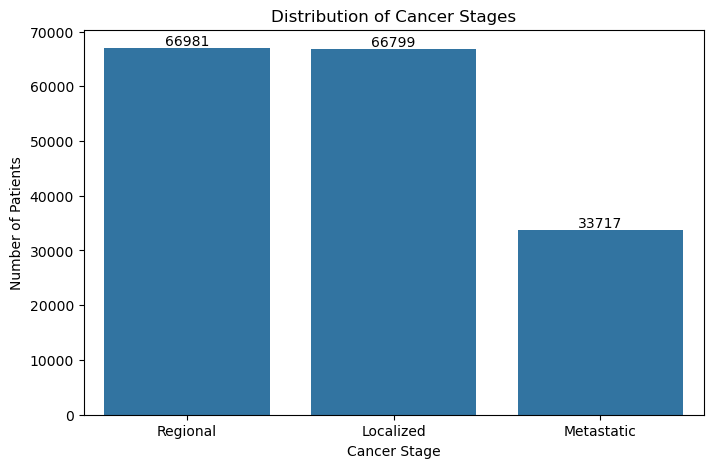

In [10]:
#visualizing cancer stage distribution using bar plot
plt.figure(figsize = (8,5))

ax = sns.barplot(
    x = "Cancer Stage",
    y = "Patient Count",
    data = stage_counts
)

plt.title("Distribution of Cancer Stages")
plt.xlabel("Cancer Stage")
plt.ylabel("Number of Patients")

for i in ax.containers:
    ax.bar_label(i)

plt.show()

In [11]:
#grouping patients by cancer stage and 5 year survival status
survival_stage = df.groupby(
    ["Cancer_Stage", "Survival_5_years"]
).size().reset_index()

survival_stage.columns = [
    "Cancer Stage",
    "5-Year Survival",
    "Patient Count"
]

survival_stage


,Cancer Stage,5-Year Survival,Patient Count
0,Localized,No,26731
1,Localized,Yes,40068
2,Metastatic,No,13565
3,Metastatic,Yes,20152
4,Regional,No,26814
5,Regional,Yes,40167


In [12]:
#adding total patient count for each cancer stage
survival_stage["Total Patients in Stage"] = survival_stage["Cancer Stage"]

In [13]:
#defining a custom order for cancer stages (clinical order)
stage_order = [
    "Localized",
    "Regional",
    "Metastatic"
]

In [14]:
#applying custom sorting to cancer stages
survival_stage["Cancer Stage"] = pd.Categorical(
    survival_stage["Cancer Stage"],
    categories = stage_order,
    ordered = True
)

survival_stage = survival_stage.sort_values("Cancer Stage")
survival_stage = survival_stage.reset_index()

survival_stage

,index,Cancer Stage,5-Year Survival,Patient Count,Total Patients in Stage
0,0,Localized,No,26731,Localized
1,1,Localized,Yes,40068,Localized
2,4,Regional,No,26814,Regional
3,5,Regional,Yes,40167,Regional
4,2,Metastatic,No,13565,Metastatic
5,3,Metastatic,Yes,20152,Metastatic


In [15]:
#renaming to avoid conflict
stage_counts = stage_counts.rename(
    columns = {"Patient Count": "Total Patient"}
)
stage_counts

,Cancer Stage,Total Patient
0,Regional,66981
1,Localized,66799
2,Metastatic,33717


In [16]:
#merge the tables
survival_stage = survival_stage.merge(
    stage_counts,
    on = "Cancer Stage"
)
survival_stage

,index,Cancer Stage,5-Year Survival,Patient Count,Total Patients in Stage,Total Patient
0,0,Localized,No,26731,Localized,66799
1,1,Localized,Yes,40068,Localized,66799
2,4,Regional,No,26814,Regional,66981
3,5,Regional,Yes,40167,Regional,66981
4,2,Metastatic,No,13565,Metastatic,33717
5,3,Metastatic,Yes,20152,Metastatic,33717


In [17]:
#filtering only patients who survived 5 years
survival_yes = survival_stage[
    survival_stage["5-Year Survival"] == "Yes"
].copy()
survival_yes

,index,Cancer Stage,5-Year Survival,Patient Count,Total Patients in Stage,Total Patient
1,1,Localized,Yes,40068,Localized,66799
3,5,Regional,Yes,40167,Regional,66981
5,3,Metastatic,Yes,20152,Metastatic,33717


In [18]:
#find the percentage of survival
survival_yes["Survival Rate"] = (survival_yes["Patient Count"] / survival_yes["Total Patient"]) *100
survival_yes

,index,Cancer Stage,5-Year Survival,Patient Count,Total Patients in Stage,Total Patient,Survival Rate
1,1,Localized,Yes,40068,Localized,66799,59.982934
3,5,Regional,Yes,40167,Regional,66981,59.967752
5,3,Metastatic,Yes,20152,Metastatic,33717,59.768070


### Interpretation of the Results

- The survival rates for all cancer stages are surprisingly close to each other, all being around 60%.

- Normally, patients with metastatic cancer are expected to have a much lower 5-year survival rate compared to patients diagnosed at a localized stage.

- Because of this, the dataset may not fully reflect real clinical patterns and could contain synthetically generated or simplified survival data.

# Correlation between smoking history and mortality

In [19]:
#grouping smoking history and mortality data
smoking_mortality = df.groupby(
    ["Smoking_History", "Mortality"]
).size().reset_index()

smoking_mortality.columns = [
    "Smoking History",
    "Mortality",
    "Patient Count"
]

smoking_mortality

,Smoking History,Mortality,Patient Count
0,No,No,59933
1,No,Yes,40208
2,Yes,No,40421
3,Yes,Yes,26935


In [20]:
#counting total patient by smoking history
smoking_totals = df["Smoking_History"].value_counts().reset_index()

smoking_totals.columns = [
    "Smoking History",
    "Total Patients"
]

smoking_totals

,Smoking History,Total Patients
0,No,100141
1,Yes,67356


In [23]:
#merging total smoking counts with mortality data
smoking_mortality = smoking_mortality.merge(
    smoking_totals,
    on = "Smoking History"
)
smoking_mortality

,Smoking History,Mortality,Patient Count,Total Patients
0,No,No,59933,100141
1,No,Yes,40208,100141
2,Yes,No,40421,67356
3,Yes,Yes,26935,67356


In [25]:
#filtering patients with mortality = yes
mortality_yes = smoking_mortality[
    smoking_mortality["Mortality"] == "Yes"
].copy()

mortality_yes

,Smoking History,Mortality,Patient Count,Total Patients
1,No,Yes,40208,100141
3,Yes,Yes,26935,67356


In [26]:
#calculating mortality rate based on smoking history
mortality_yes["Mortality Rate"] = (mortality_yes["Patient Count"] / mortality_yes["Total Patients"]) * 100

mortality_yes["Mortality Rate"] = mortality_yes["Mortality Rate"].round(2)

mortality_yes

,Smoking History,Mortality,Patient Count,Total Patients,Mortality Rate
1,No,Yes,40208,100141,40.15
3,Yes,Yes,26935,67356,39.99


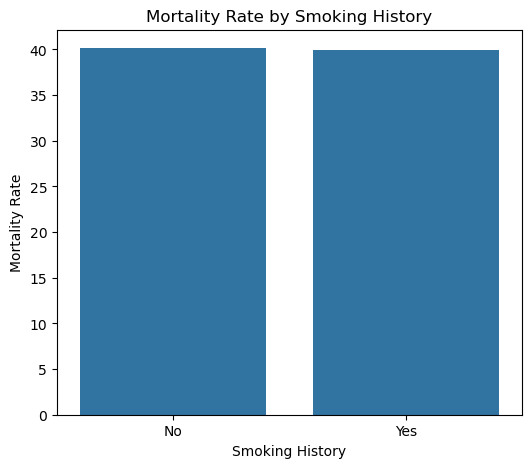

In [27]:
#visualizing mortality rates based on the smoking history
plt.figure(figsize=(6,5))

sns.barplot(
    x= "Smoking History",
    y = "Mortality Rate",
    data = mortality_yes
)

plt.title("Mortality Rate by Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Mortality Rate")

plt.show()

## Key Findings

- Survival rates across cancer stages appeared unrealistically similar.
- Smoking history showed little difference in mortality rates.
- Several relationships in the dataset may be synthetically generated or weakly correlated.
  